In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
wb_df = pd.read_csv('parsed/wb_data.csv')
wb_df.head()

,id,brand,name,price,old_price,discount,rating,reviews,link,search_url
0,695213222,ART&FACT.,Шампунь для жирных волос очищающий 400 мл,502,9462.0,NaN,"4,8",1264.0,https://www.wildberries.ru/catalog/695213222/d...,https://www.wildberries.ru/catalog/0/search.as...
1,791357100,ART&FACT.,"Сыворотка для лица с витамином С, набор 1+1",680,1710.0,NaN,"4,7",17219.0,https://www.wildberries.ru/catalog/791357100/d...,https://www.wildberries.ru/catalog/0/search.as...
2,44151357,ART&FACT.,"Лосьон для лица от акне и комедонов, 150 мл",525,2890.0,NaN,"4,7",10425.0,https://www.wildberries.ru/catalog/44151357/de...,https://www.wildberries.ru/catalog/0/search.as...
3,158573601,ART&FACT.,Пенка для умывания от прыщей,384,11020.0,NaN,"4,8",23762.0,https://www.wildberries.ru/catalog/158573601/d...,https://www.wildberries.ru/catalog/0/search.as...
4,694507304,ART&FACT.,"Шампунь для волос от выпадения, 400 мл",411,7753.0,NaN,"4,8",1264.0,https://www.wildberries.ru/catalog/694507304/d...,https://www.wildberries.ru/catalog/0/search.as...


В первую очередь необходимо посмотреть, правильно ли спарсились бренды, а также нет ли такого, что один и тот же бренд мог спарситься по разному (к примеру, есть лишняя точка и тп) 

In [55]:
wb_df['brand'].nunique()

1001

In [56]:
wb_df['brand'].unique()

<StringArray>
[     'ART&FACT.',       'ART&FACT',              nan,     'ART & FACT',
     'Нет бренда',      'Sergerico',         'Лосьон',        'Гельтек',
          'The U', 'Гельтек-Медика',
 ...
         'DESOON',         'АВГУСТ',          'BOSCH',  'сушеное манго',
       'Садовита',         'Jetdry',           'Nart',          'Disat',
          'Эксмо',         'LOREAL']
Length: 1002, dtype: str

Подтверждаем теорию, что бренды спарсились разными способами (к примеру, ART&FACT., ART&FACT и ART & FACT)

Также есть бренды, которые мы изначально не запрашивали (BOSCH, сушеное манго)

Выделим только требуемые бренды и посмотрим статистику

In [57]:
def map_brand(name):
    name = str(name).lower()
    if 'art' in name:
        return 'art&fact'
    if 'гельтек' in name:
        return 'geltekcosmetics'
    if 'mixit' in name:
        return 'mixit'
    if 'icon' in name:
        return 'iconskin'
    if 'wetty' in name:
        return 'wetty_lab'
    if 'the u' in name:
        return 'theu_club'
    if 'openface' in name:
        return 'openface'
    if 'librederm' in name:
        return 'librederm'
    if 'aravia' in name:
        return 'aravia'
    if 'natura' in name:
        return 'natura'
    if 'vois' in name:
        return 'vois'
    if 'oreal' in name:
        return 'lorealparis'
    if 'beauty' in name:
        return 'beautybomb'
    
    return 'Нет бренда'

wb_df['brand'] = wb_df['brand'].apply(map_brand)

In [58]:
wb_df['brand'].unique()

<StringArray>
[       'art&fact',      'Нет бренда', 'geltekcosmetics',       'theu_club',
        'iconskin',     'lorealparis',           'mixit',      'beautybomb',
       'wetty_lab',        'openface',       'librederm',          'aravia',
          'natura',            'vois']
Length: 14, dtype: str

In [59]:
wb_df.shape

(19881, 10)

In [60]:
wb_df.groupby('brand')['name'].count()

brand
aravia             1000
art&fact           1069
beautybomb         2105
geltekcosmetics    1976
iconskin            570
librederm          1598
lorealparis        1580
mixit              1136
natura             1198
openface             82
theu_club             6
vois                253
wetty_lab             5
Нет бренда         7298
Name: name, dtype: int64

Можно увидеть, что спарсились около 7000 ненужных нам брендов, поэтому избавимся от этих записей

In [61]:
wb_df = wb_df[wb_df['brand'] != 'Нет бренда'].copy()

In [62]:
wb_df.groupby('brand')['name'].count()

brand
aravia             1000
art&fact           1069
beautybomb         2105
geltekcosmetics    1976
iconskin            570
librederm          1598
lorealparis        1580
mixit              1136
natura             1198
openface             82
theu_club             6
vois                253
wetty_lab             5
Name: name, dtype: int64

In [63]:
wb_df.shape

(12578, 10)

Посмотрим далее на колонки, а также, что они обозначают

In [64]:
wb_df.info()

<class 'pandas.DataFrame'>
Index: 12578 entries, 0 to 19880
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          12578 non-null  int64  
 1   brand       12578 non-null  str    
 2   name        12578 non-null  str    
 3   price       12578 non-null  int64  
 4   old_price   12578 non-null  float64
 5   discount    0 non-null      float64
 6   rating      9100 non-null   str    
 7   reviews     9100 non-null   float64
 8   link        12578 non-null  str    
 9   search_url  12578 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 1.1 MB


Ни у одного товара нет скидки, избавимся от этого столбца

Также для анализа рейтинга и успешности товара колонки, содержащие ссылки, не имеют ценности, поэтому также избавимся от них

Рейтинг почему-то является строковым значением, хотя должен быть тип float()

In [65]:
wb_df.drop(columns=['discount', 'link', 'search_url'], inplace=True)
wb_df.info()

<class 'pandas.DataFrame'>
Index: 12578 entries, 0 to 19880
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         12578 non-null  int64  
 1   brand      12578 non-null  str    
 2   name       12578 non-null  str    
 3   price      12578 non-null  int64  
 4   old_price  12578 non-null  float64
 5   rating     9100 non-null   str    
 6   reviews    9100 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 786.1 KB


In [66]:
wb_df[wb_df['rating'].isna()].shape[0] / wb_df.shape[0] * 100

27.65145492129114

In [67]:
wb_df['rating'] = wb_df['rating'].str.replace(',', '.')
wb_df['rating'] = wb_df['rating'].astype('float')

Заметим, что практически 30% записей не имею рейтинга, это могут быть непопулярные товары, или товары, которые купили, но не оставили отзыв, или еще не раскрученные товары

По логике все строки, не имеюшие рейтинга, должны не иметь отзывов, проверим это

In [68]:
no_rating = wb_df[(wb_df['rating'].isna()) & (wb_df['reviews'].isna())]
no_rating.shape

(3478, 7)

Так и есть, так как 12578 - 9100 = 3478

Посмотрим какой процент от каждого бренда не имеет отзывов и рейтинга

In [69]:
no_rating_stat = no_rating.groupby('brand')['name'].count().reset_index()
wb_df_stat = wb_df.groupby('brand')['name'].count().reset_index()

no_rating_stat.rename(columns={'name': 'missing'}, inplace=True)
wb_df_stat.rename(columns={'name': 'all'}, inplace=True)

df_stat = pd.merge(wb_df_stat, no_rating_stat, on='brand', how='left')
df_stat['stat'] = df_stat['missing'] / df_stat['all'] * 100
df_stat

,brand,all,missing,stat
0,aravia,1000,97.0,9.700000
1,art&fact,1069,358.0,33.489242
2,beautybomb,2105,831.0,39.477435
3,geltekcosmetics,1976,966.0,48.886640
4,iconskin,570,249.0,43.684211
5,librederm,1598,530.0,33.166458
6,lorealparis,1580,158.0,10.000000
7,mixit,1136,43.0,3.785211
8,natura,1198,140.0,11.686144
9,openface,82,20.0,24.390244


In [70]:
mas = []
for id in wb_df['id']:
    mas.append(len(str(id)))
set(mas)

{7, 8, 9}

Есть три показателя (цена, старая цена, колисетво отзывов/рейтинг), было бы хорошо оценить их взаимосвязь. Так как страя цена - это цена, которую мы видим зачеркнутой, когда заходим на карточку товара, попробуем использовать цену и страрую цену, чтобы посмотреть размер скидки, и как она взаимосвязана с количеством отзывов

В дальнейщем этот показатель поможет нам, чтобы оценить, не вызвана ли популярность продуктов тем, что человек видит, что продукт может стоит якобы 11к, но сейчас продается всего за 1000 рублей, а не раскрученностью товара в вк паблике. То есть исключим эффект влияния популярности в вк, если продаваемость товара на самом деле зависит от "скидки"

In [73]:
wb_df['discount'] = (wb_df['old_price'] - wb_df['price'])/ wb_df['old_price'] * 100
wb_df.head()

,id,brand,name,price,old_price,rating,reviews,discount
0,695213222,art&fact,Шампунь для жирных волос очищающий 400 мл,502,9462.0,4.8,1264.0,94.694568
1,791357100,art&fact,"Сыворотка для лица с витамином С, набор 1+1",680,1710.0,4.7,17219.0,60.233918
2,44151357,art&fact,"Лосьон для лица от акне и комедонов, 150 мл",525,2890.0,4.7,10425.0,81.833910
3,158573601,art&fact,Пенка для умывания от прыщей,384,11020.0,4.8,23762.0,96.515426
4,694507304,art&fact,"Шампунь для волос от выпадения, 400 мл",411,7753.0,4.8,1264.0,94.698826


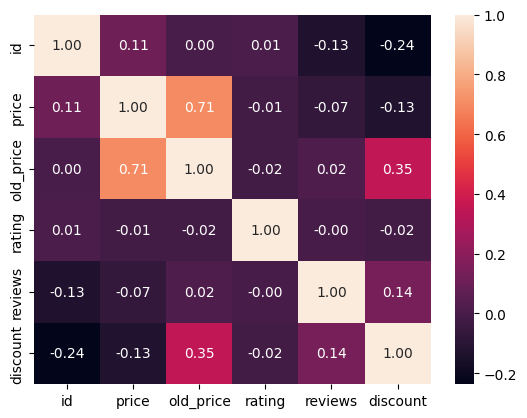

In [74]:
sns.heatmap(wb_df.corr(numeric_only=True), fmt='.2f', annot=True)
plt.show()

Можно увидеть слабую положительную зависимость между скидкой и количеством отзывов, то есть чем больше скидка, тем больше отзывов (то есть заказывают товар). Поэтому не можем исключить эффект "скидки"

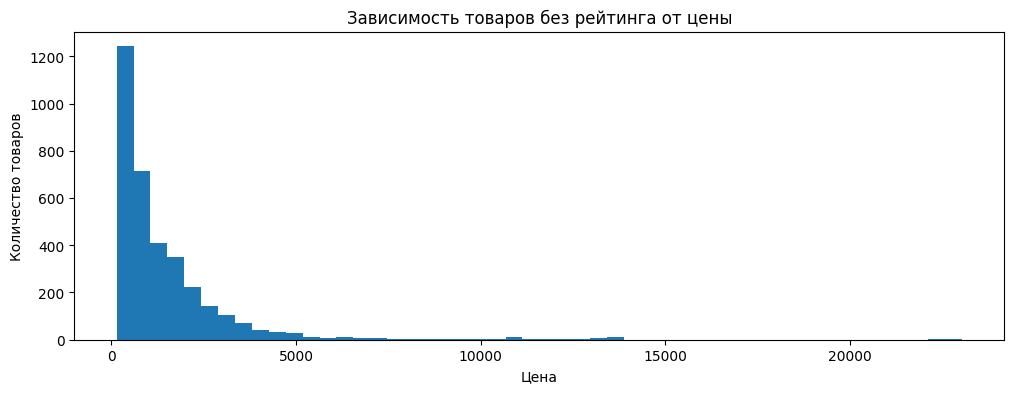

In [78]:
no_rating = wb_df[(wb_df['rating'].isna()) & (wb_df['reviews'].isna())]

plt.figure(figsize=(12, 4))

plt.hist(no_rating['price'],  bins=50)
plt.title('Зависимость товаров без рейтинга от цены')
plt.xlabel('Цена')
plt.ylabel('Количество товаров')

plt.show()

Заметим, что очень мало товаров, которые не имеют рейтинга, с высокими ценами, чаще это товары с низкими ценами

Можем предположить, что у таких товаров либо не было упоминаний в группе (или это были новые товары) или нераскрученные товары (было мало упоминаний в группе)

Не будем пока отказываться от этих данных, сопоставим их позже с данными из пабликов ВК



Запишем обработанные данные в отдельный файл, чтобы дальше использовать для анализа данных с вк

In [81]:
wb_df.to_csv('wb_eda.csv', index=False)